In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sqlite3
from scipy.stats import ttest_ind
import logging
warnings.filterwarnings('ignore')

In [2]:
conn  = sqlite3.connect('inventory.db')

In [14]:
df = pd.read_sql("""SELECT * FROM vendor_sales_summary""",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchasedDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [9]:
#Summary Stats

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchasedQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchasedDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


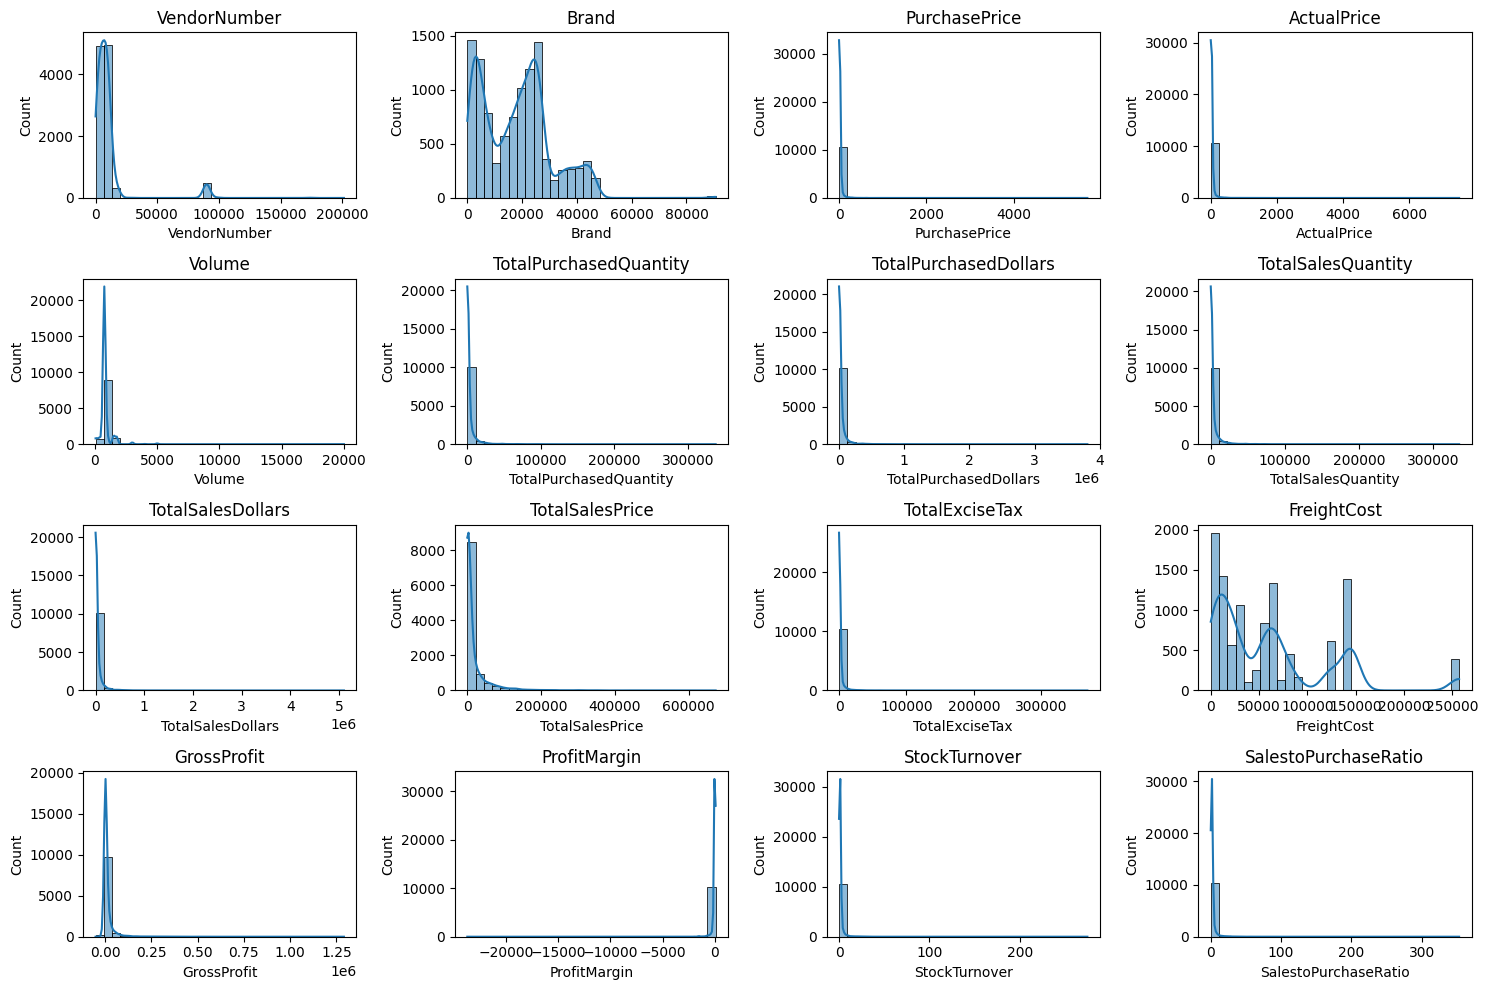

In [16]:
#Distribution plot for numerical columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col] , kde = True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

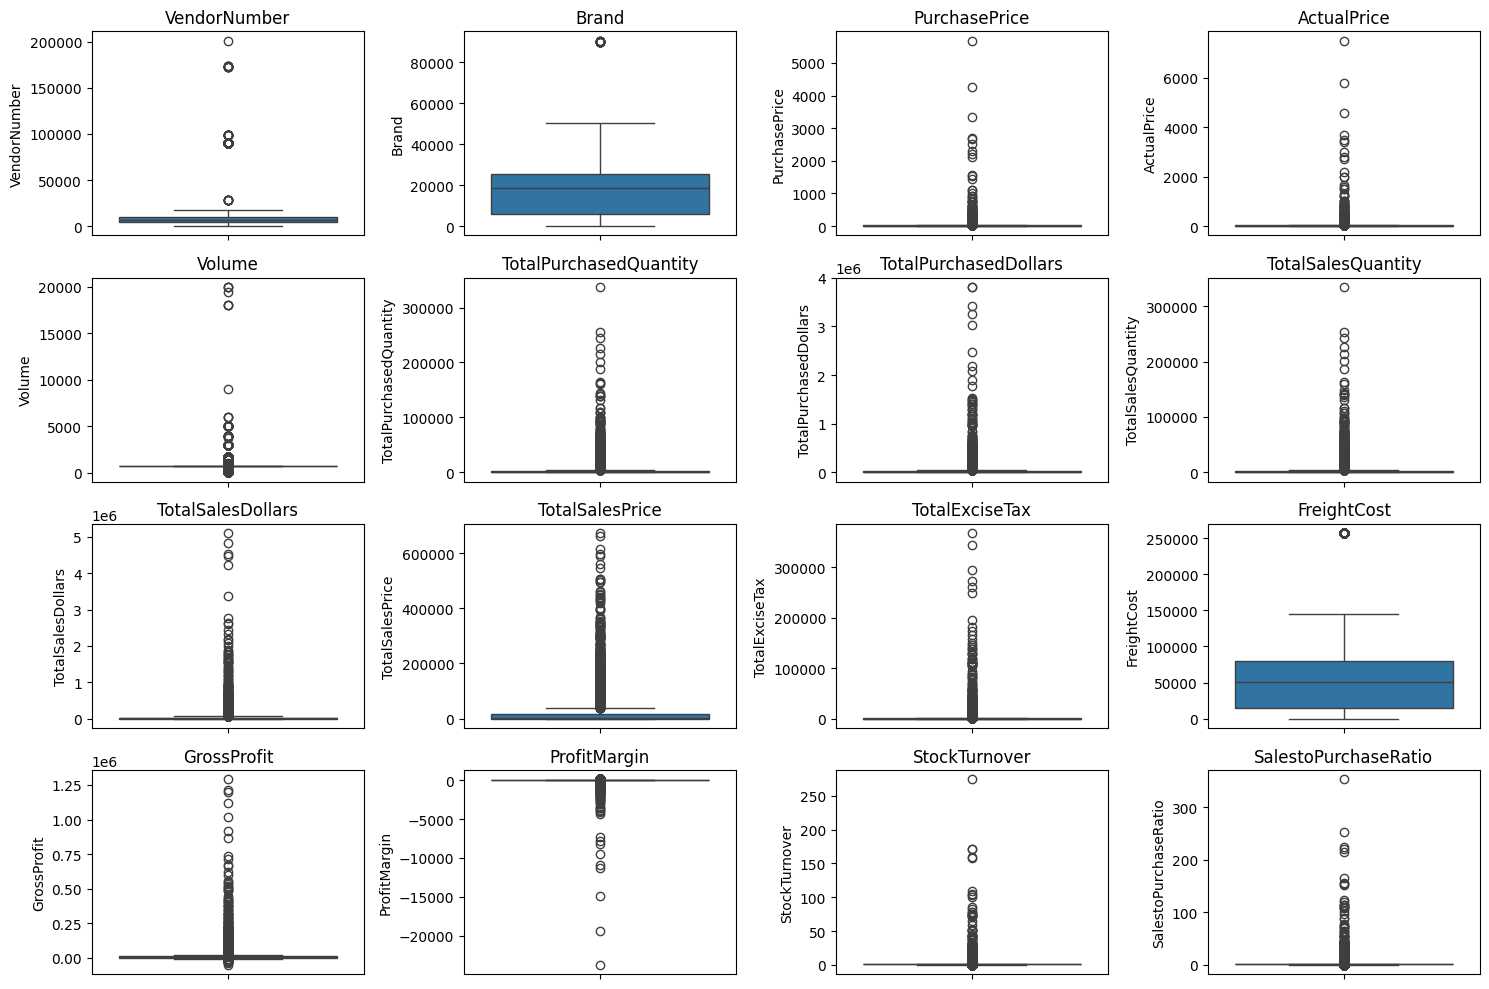

In [17]:
#Distribution plot for numerical columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [22]:
#filter the data by filtering the inconsistencies
df_filter = pd.read_sql("""SELECT * FROM 
vendor_sales_summary 
WHERE GrossProfit > 0 
AND ProfitMargin > 0 
AND TotalSalesQuantity > 0""",conn)

In [23]:
df_filter.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchasedDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


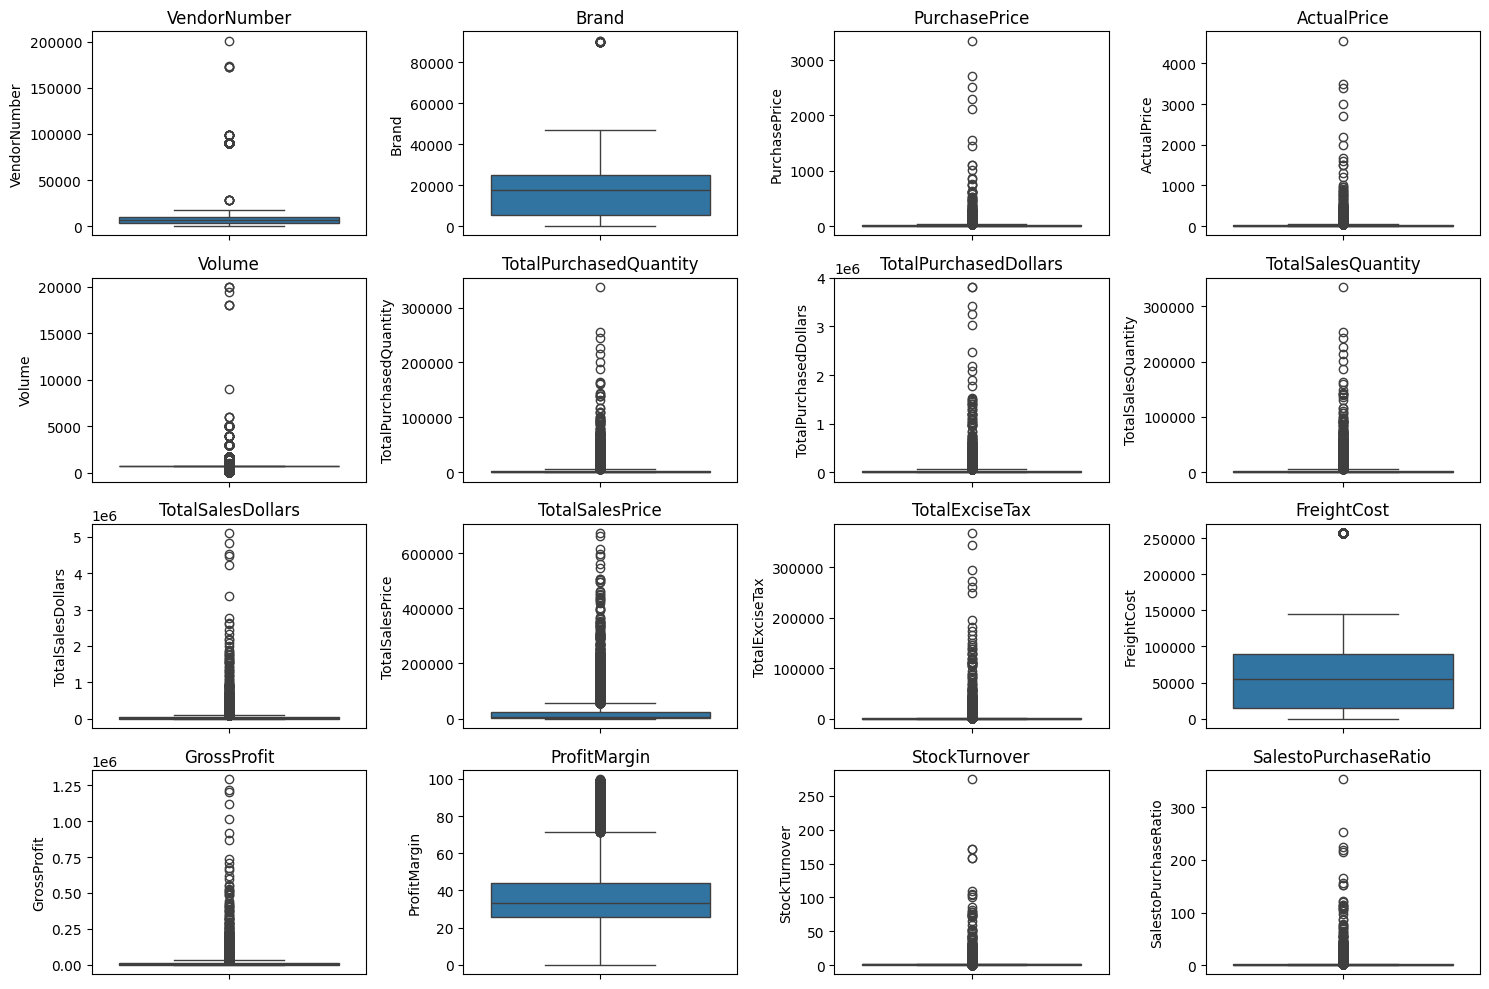

In [24]:
#Distribution plot for numerical columns
numerical_cols = df_filter.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

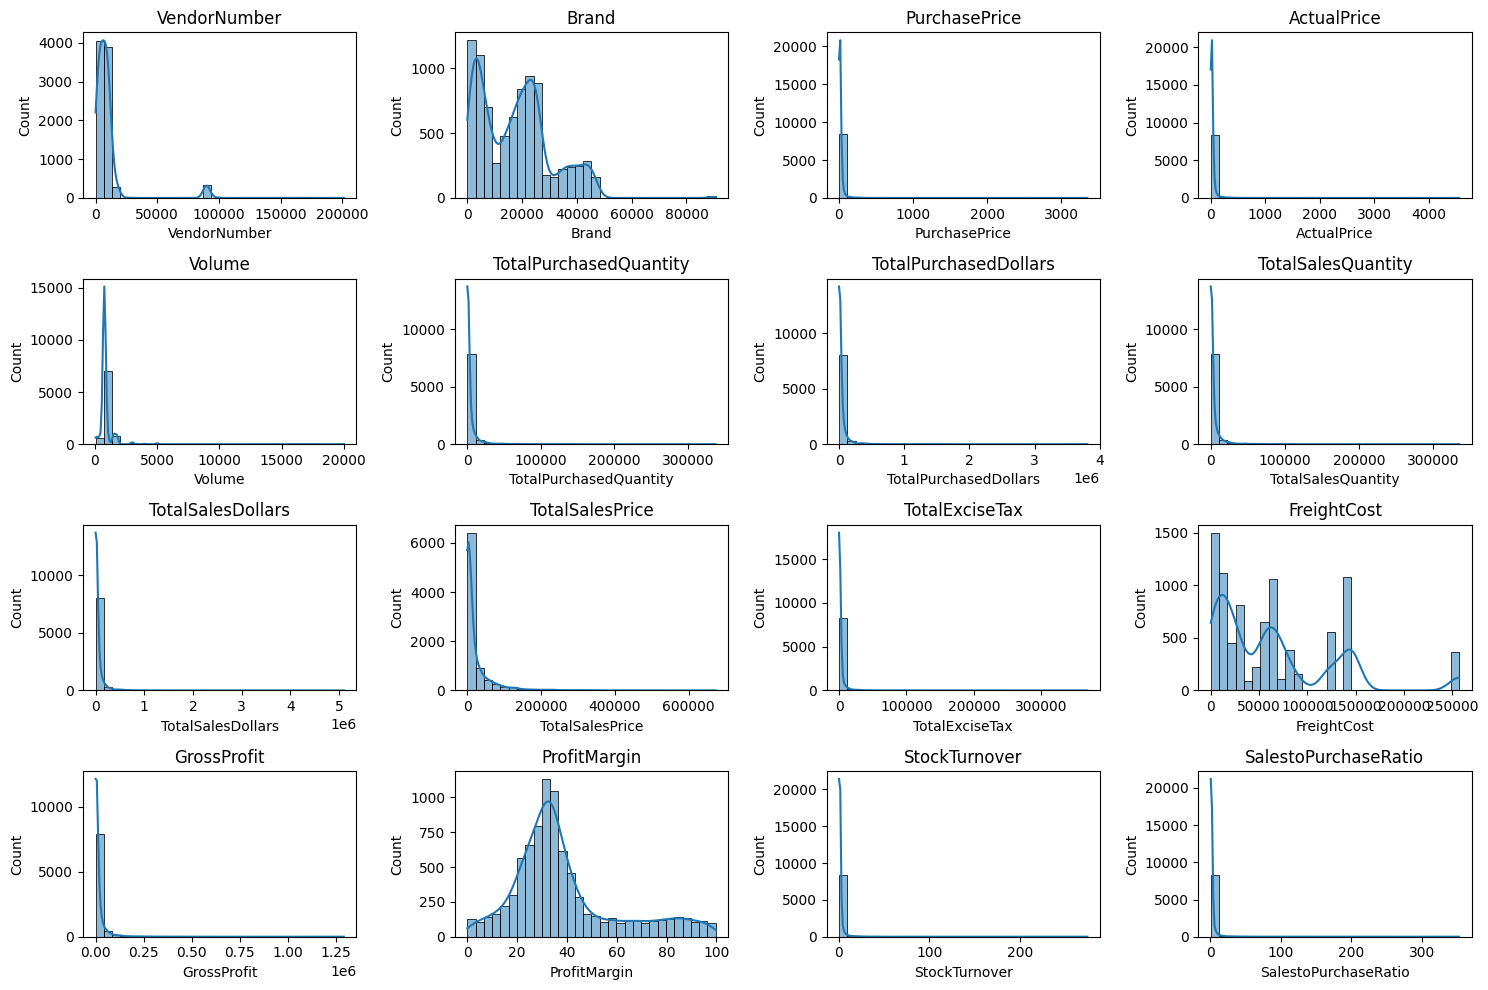

In [25]:
#Distribution plot for numerical columns
numerical_cols = df_filter.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col] , kde = True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

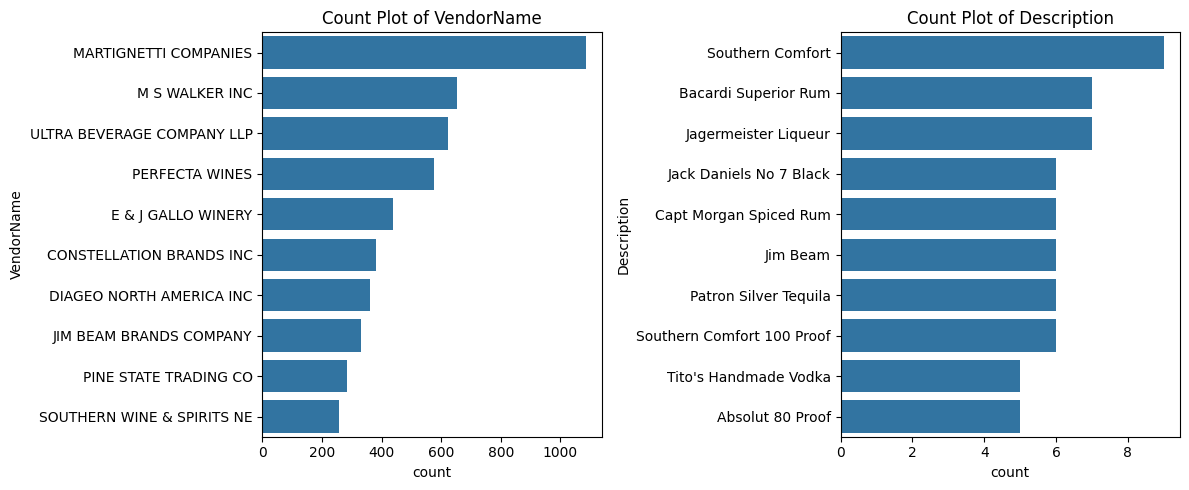

In [29]:
#count plot for categorical columns
categorical_cols = ["VendorName","Description"]
plt.figure(figsize = (12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y = df_filter[col] , order = df_filter[col].value_counts().index[:10]) #top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

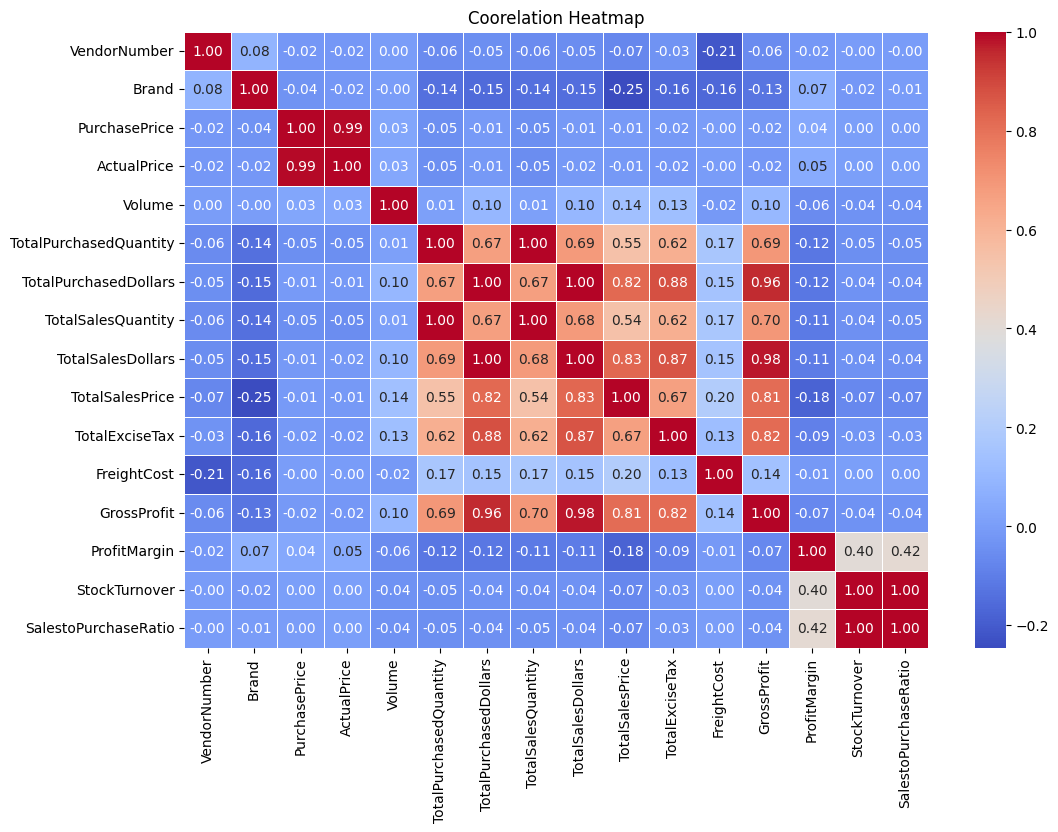

In [30]:
#correlation in Numerical Data - Heatmap
plt.figure(figsize = (12,8))
correlation_matrix = df_filter[numerical_cols].corr()
sns.heatmap(correlation_matrix , annot = True , fmt = ".2f", cmap = "coolwarm" , linewidths = 0.5)
plt.title("Coorelation Heatmap")
plt.show()

In [45]:
# Problem 01

In [33]:
brand_performance = df_filter.groupby("Description").agg({
    'TotalSalesDollars' :'sum',
    'ProfitMargin' : 'mean'
})

In [34]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [40]:
low_sales_threshold

np.float64(560.299)

In [36]:
high_margin_threshold

np.float64(64.97017552750111)

In [41]:
#Targeted Brands
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brand with low Sales and High Profit Margin")
display(target_brands.sort_values('TotalSalesDollars'))

Brand with low Sales and High Profit Margin


,TotalSalesDollars,ProfitMargin
Description,,
Santa Rita Organic Svgn Bl,9.99,66.466466
Debauchery Pnt Nr,11.58,65.975820
Concannon Glen Ellen Wh Zin,15.95,83.448276
Crown Royal Apple,27.86,89.806174
Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...
Nanbu Bijin Southern Beauty,535.68,76.747312
Dad's Hat Rye Whiskey,538.89,81.851584
A Bichot Clos Marechaudes,539.94,67.740860


In [43]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000] #for better Visualization

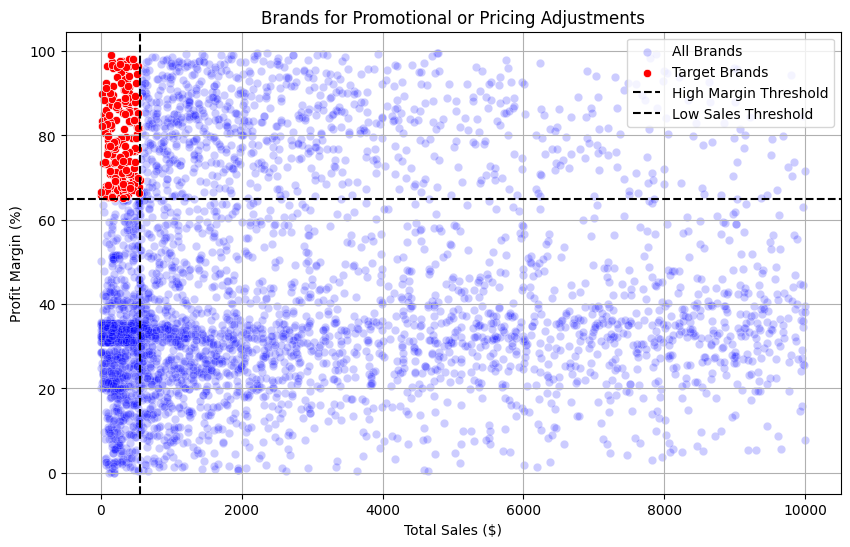

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional or Pricing Adjustments')

plt.legend()
plt.grid(True)

plt.show()

In [46]:
# Problem 02

In [55]:
# Top Vendors and Brands by Sales and Performances
top_vendors = df_filter.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df_filter.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

top_vendors


VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

In [56]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [54]:
def format_dollars(value):
    if value >= 1_000_000:#1M
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:#1K
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [57]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

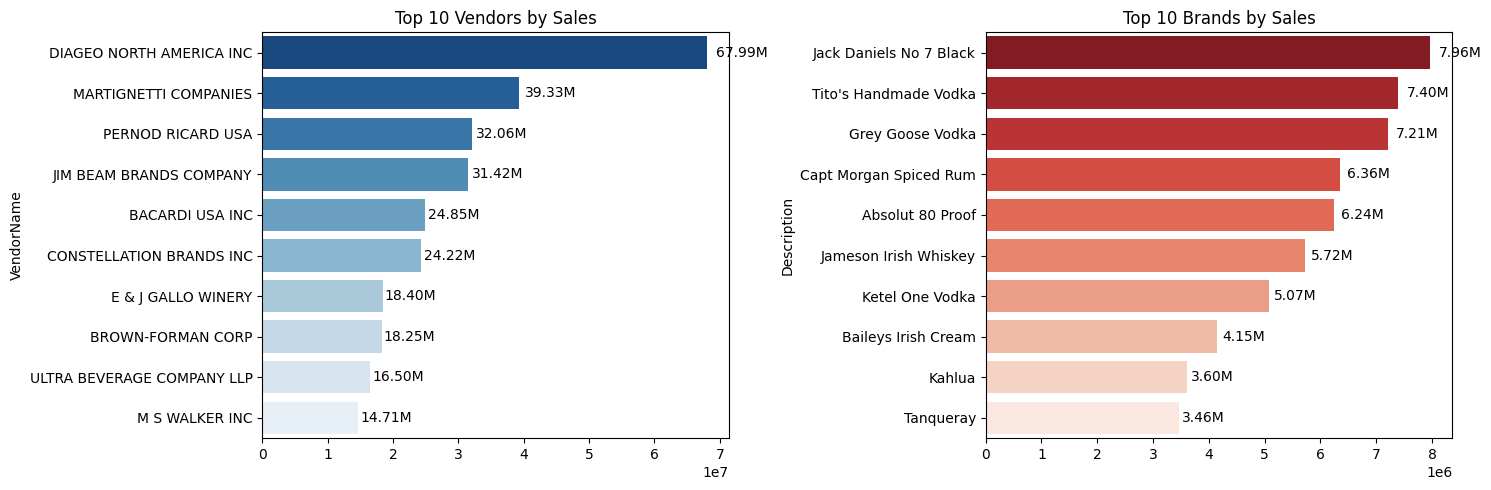

In [58]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

In [60]:
# Which Vendors contribute the most to the total Purchase dollars

In [89]:
vendor_performance = brand_performance = df_filter.groupby("VendorName").agg({
    'TotalSalesDollars' :'sum',
    'TotalPurchasedDollars' : 'sum',
    'GrossProfit' : 'sum'
}).reset_index()

vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchasedDollars'] / vendor_performance['TotalPurchasedDollars'].sum() *100

In [90]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%' , ascending = False) , 2)

In [91]:
#top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(lambda x : format_dollars(x))
top_vendors['TotalPurchasedDollars'] = top_vendors['TotalPurchasedDollars'].apply(lambda x : format_dollars(x))
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(lambda x : format_dollars(x))
top_vendors

,VendorName,TotalSalesDollars,TotalPurchasedDollars,GrossProfit,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,67.99M,50.10M,17.89M,16.30
57,MARTIGNETTI COMPANIES,39.33M,25.50M,13.83M,8.30
68,PERNOD RICARD USA,32.06M,23.85M,8.21M,7.76
46,JIM BEAM BRANDS COMPANY,31.42M,23.49M,7.93M,7.64
6,BACARDI USA INC,24.85M,17.43M,7.42M,5.67
20,CONSTELLATION BRANDS INC,24.22M,15.27M,8.95M,4.97
11,BROWN-FORMAN CORP,18.25M,13.24M,5.01M,4.31
30,E & J GALLO WINERY,18.40M,12.07M,6.33M,3.93
106,ULTRA BEVERAGE COMPANY LLP,16.50M,11.17M,5.34M,3.63
53,M S WALKER INC,14.71M,9.76M,4.94M,3.18


In [76]:
top_vendors['PurchaseContribution%'].sum()

np.float64(0.6600000000000001)

In [92]:
top_vendors['CummulativeContribution%'] = top_vendors['PurchaseContribution%'].cumsum()

In [93]:
top_vendors

,VendorName,TotalSalesDollars,TotalPurchasedDollars,GrossProfit,PurchaseContribution%,CummulativeContribution%
25,DIAGEO NORTH AMERICA INC,67.99M,50.10M,17.89M,16.30,16.30
57,MARTIGNETTI COMPANIES,39.33M,25.50M,13.83M,8.30,24.60
68,PERNOD RICARD USA,32.06M,23.85M,8.21M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,31.42M,23.49M,7.93M,7.64,40.00
6,BACARDI USA INC,24.85M,17.43M,7.42M,5.67,45.67
20,CONSTELLATION BRANDS INC,24.22M,15.27M,8.95M,4.97,50.64
11,BROWN-FORMAN CORP,18.25M,13.24M,5.01M,4.31,54.95
30,E & J GALLO WINERY,18.40M,12.07M,6.33M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,16.50M,11.17M,5.34M,3.63,62.51
53,M S WALKER INC,14.71M,9.76M,4.94M,3.18,65.69


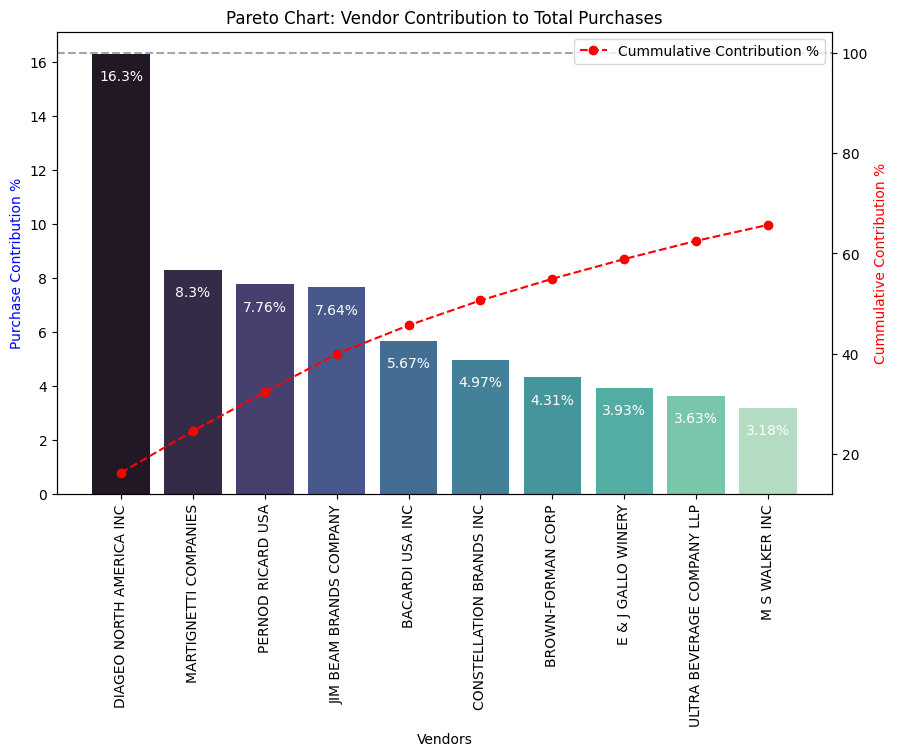

In [94]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar Plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['CummulativeContribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cummulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cummulative Contribution %', color='red')

ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.show()

In [97]:
# How much of Total Procurement is dependent on Top Vendors

In [102]:
print(f"total Purchase Contribution from Top Vendors {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

total Purchase Contribution from Top Vendors 65.69 %


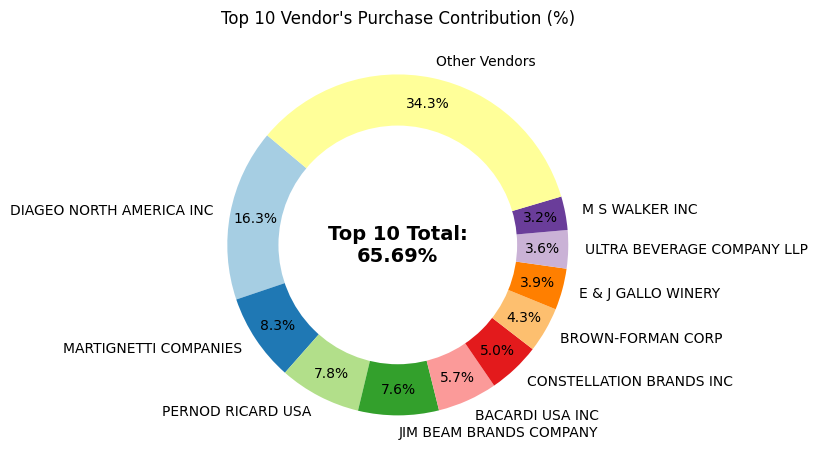

In [104]:
vendors = list(top_vendors['VendorName'].values)

purchase_contributions = list(
    top_vendors['PurchaseContribution%'].values
)

total_contribution = sum(purchase_contributions)

remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.tight_layout()
plt.show()

In [109]:
df_filter['OrderPrice'] = df_filter['TotalPurchasedDollars'] / df_filter['TotalPurchasedQuantity']

In [110]:
df_filter.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchasedDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,OrderPrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89


In [111]:
df_filter['OrderSize'] = pd.qcut(df_filter['TotalPurchasedQuantity'] , q=3 , labels = ["Small","Medium","Large"])
df_filter.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchasedDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,OrderPrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large


In [113]:
df_filter.groupby('OrderSize')[['OrderPrice']].mean()

,OrderPrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


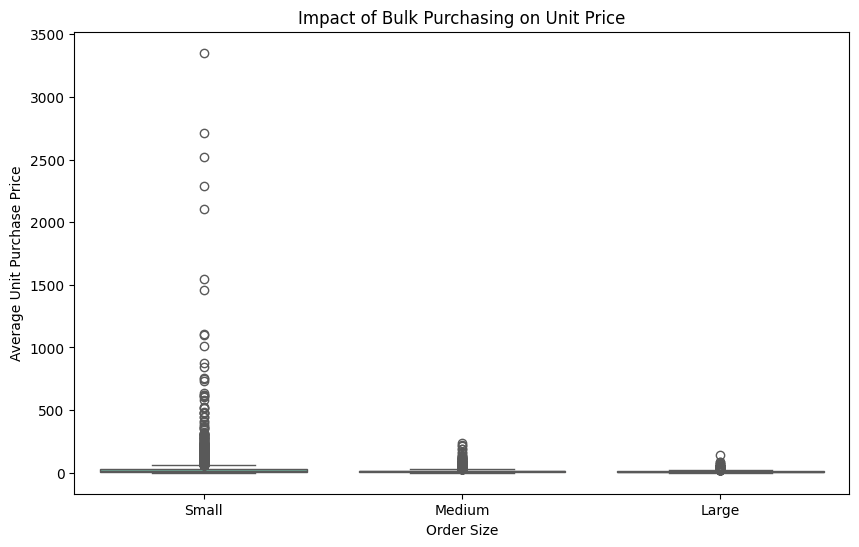

In [116]:
plt.figure(figsize = (10 , 6))
sns.boxplot(data = df_filter , x = "OrderSize" , y = "OrderPrice" , palette = "Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [117]:
# Which Vendors have low inventory turnover , indicating excess stock and slow moving products?

In [122]:
df_filter[df_filter['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover' , ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [123]:
# How much Capital is locked in Unsold inventory per Vendor , and which vendor contribute the most to it?

In [124]:
df_filter['UnsoldInventoryValue'] = (df_filter['TotalPurchasedQuantity'] - df_filter['TotalSalesQuantity']) * df_filter['OrderPrice']

In [126]:
print("total unsold inventory capital is" , format_dollars(df_filter['UnsoldInventoryValue'].sum()))

total unsold inventory capital is 2.71M


In [128]:
inventory_value_per_vendor = df_filter.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()
inventory_value_per_vendor = inventory_value_per_vendor.sort_values('UnsoldInventoryValue' , ascending = False)

inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(lambda x : format_dollars(x))
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


In [129]:
# What is 95% Confidence Interval for Profit Margins of Top-Performing or Low-Performing Vendors

In [131]:
top_threshold = df_filter['TotalSalesDollars'].quantile(0.75)
low_threshold = df_filter['TotalSalesDollars'].quantile(0.25)

In [132]:
top_vendors = df_filter[df_filter['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df_filter[df_filter['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [135]:
from scipy import stats
def confidence_interval(data , confidence = 0.95):
    mean_val = np.mean(data)
    std_err = np.std(data , ddof = 1) / np.sqrt(len(data)) #standard error
    t_critical = stats.t.ppf((1 + confidence)/2 , df = len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val , mean_val - margin_of_error , mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


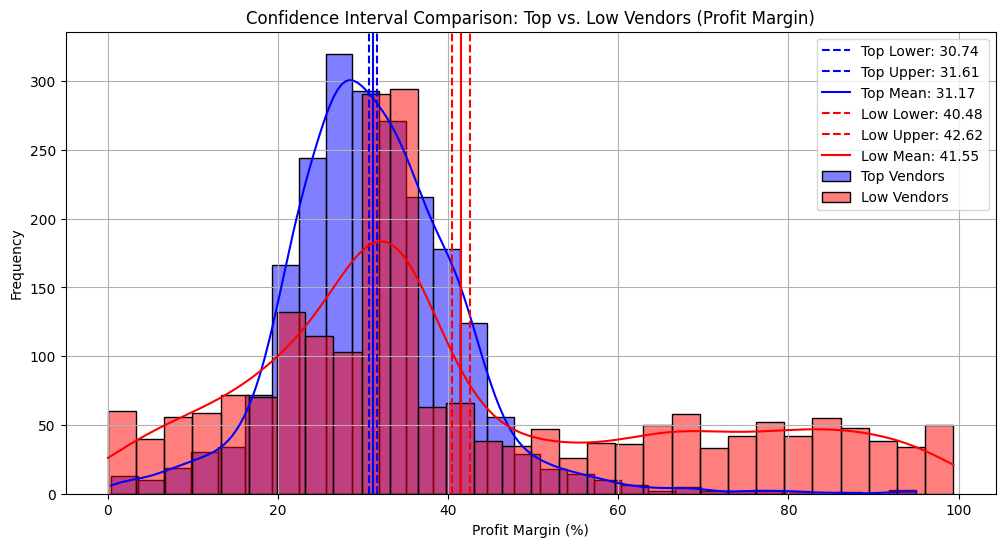

In [136]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)

plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors Plot
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)

plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'",conn)
tables

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,sales
5,vendor_invoice
6,vendor_sales_summary
